# Calibración — Sprint 2

Diagnósticos del optimizador GA para diseño de vigas de N tramos.

| Sección | Análogo en ML clásico |
|---|---|
| Curvas de convergencia | Learning curves (loss vs epoch) |
| Ablaciones multi-seed | Baseline vs Var1 vs Var2 por fold |
| Desglose de penalizaciones | Importancia de variables |
| Tasa de factibilidad | Calibración (predicción vs realidad) |
| Log JSON con timestamp | Logs completos (config, métricas) |

In [ ]:
%matplotlib inline
import sys, os, json, time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from beam_n import BeamGANSpans, ensure_joints
from beam_n.config_n import generate_zone_ids

print('Imports OK — ROOT:', ROOT)

Imports OK — ROOT: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl


## Configuración global

In [2]:
# ── Semillas fijas (reproducibilidad) ─────────────────────────────────────────
SEEDS = [42, 123, 7]

# ── Modo quick (demo) vs completo ─────────────────────────────────────────────
QUICK = True          # True: pop=80, gen=60  |  False: auto-scaling por n_spans
POP_QUICK = 80
GEN_QUICK = 60

# ── Rutas de beams extraidos desde ETABS ─────────────────────────────────────
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

BEAM_FILES = sorted(DATA_DIR.glob('beam_*.json'))   # se llena en la sección 0
print(f'Beams encontrados: {[f.name for f in BEAM_FILES]}')

# ── Carpeta de salida ────────────────────────────────────────────────────────
OUT_DIR = ROOT / 'notebooks' / 'output'
OUT_DIR.mkdir(exist_ok=True)
print(f'Salida en: {OUT_DIR}')

Beams encontrados: ['beam_viga_1_tramos.json', 'beam_viga_2_tramos.json', 'beam_viga_3_tramos.json']
Salida en: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output


---
## 0. Extracción desde ETABS

**Instrucciones:**
1. Abre ETABS con el modelo analizado.
2. Selecciona los frames de **una** viga continua.
3. Cambia `BEAM_TAG` y ejecuta la celda.
4. Repite para cada viga (simple, media, compleja).

> Omite esta sección si los JSONs ya están en `data/`.

In [3]:
EXTRACT_FROM_ETABS = False   # Cambiar a True cuando ETABS esté abierto

# Parámetros de extracción
FC       = 210.0    # kg/cm2
COMBO    = 'ENV'    # nombre del combo de envolvente en ETABS
BEAM_TAG = 'viga_1_tramos' # etiqueta libre para identificar el archivo

if EXTRACT_FROM_ETABS:
    from beam_n.etabs_extractor_n import extract_multispan_beam
    beam = extract_multispan_beam(fc_kg_cm2=FC, combo=COMBO)
    ensure_joints(beam)   # agrega joints con h_col=0.30 por defecto

    out_path = DATA_DIR / f'beam_{BEAM_TAG}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(beam, f, indent=2, ensure_ascii=False)

    print(f"Guardado: {out_path}")
    print(f"  id={beam['id']}, n_spans={beam['n_spans']}")
    print(f"  b={beam['inputs']['b_m']}m, h={beam['inputs']['h_m']}m")
    for i, sp in enumerate(beam['spans']):
        print(f"  T{i+1}: L={sp['L_m']:.2f}m")
else:
    print('Extracción ETABS omitida — cargando JSONs existentes.')

Extracción ETABS omitida — cargando JSONs existentes.


---
## 1. Cargar beams de prueba

In [4]:
BEAM_FILES = sorted(DATA_DIR.glob('beam_*.json'))

if not BEAM_FILES:
    raise FileNotFoundError(
        'No hay archivos beam_*.json en data/. '
        'Ejecuta la sección 0 con ETABS o coloca los JSONs manualmente.'
    )

beams = []
for p in BEAM_FILES:
    with open(p, encoding='utf-8') as f:
        b = json.load(f)
    ensure_joints(b)
    beams.append(b)
    print(f"{p.name}: id={b['id']}, "
          f"n_spans={b['n_spans']}, "
          f"b={b['inputs']['b_m']}m, h={b['inputs']['h_m']}m, "
          f"fc={b['inputs']['fc_kg_cm2']} kg/cm2")

beam_viga_1_tramos.json: id=28, n_spans=1, b=0.15m, h=0.45m, fc=210.0 kg/cm2
beam_viga_2_tramos.json: id=110+114, n_spans=2, b=0.25m, h=0.55m, fc=210.0 kg/cm2
beam_viga_3_tramos.json: id=18+17+16, n_spans=3, b=0.25m, h=0.55m, fc=210.0 kg/cm2


---
## 2. Ablaciones — multi-seed

Mismo beam, mismas seeds, misma config → medir estabilidad.
Se recorre cada viga × cada seed y se guarda la tabla de resultados.

In [5]:
def run_experiment(beam, seed, quick=QUICK):
    """Corre el GA y retorna un dict con métricas y la historia."""
    pop = POP_QUICK if quick else None
    gen = GEN_QUICK if quick else None

    ga = BeamGANSpans(beam, pop_size=pop, n_gen=gen, seed=seed)
    t0 = time.time()
    result = ga.run()
    elapsed = time.time() - t0

    top = result['top3'][0]
    n_zones = ga.n_zones

    # Generación de convergencia: primera gen donde best_fit < 5% del maximo
    hist = result['history_best']
    best_final = hist[-1]
    conv_gen = next(
        (i for i, v in enumerate(hist) if v <= best_final * 1.05),
        len(hist)
    )

    return {
        'beam_id'     : beam['id'],
        'n_spans'     : beam['n_spans'],
        'b_m'         : beam['inputs']['b_m'],
        'h_m'         : beam['inputs']['h_m'],
        'seed'        : seed,
        'pop'         : ga.pop_size,
        'n_gen'       : ga.n_gen,
        'weight_kg'   : round(top['total_weight_kg'], 2),
        'fitness'     : round(top['fitness'], 4),
        'feasible'    : top['feasible'],
        'zones_ok'    : top['zones_ok'],
        'n_zones'     : n_zones,
        'feas_rate'   : round(top['zones_ok'] / n_zones, 3),
        'conv_gen'    : conv_gen,
        'time_s'      : round(elapsed, 1),
        'violations'  : top['violations'],
        'history_best': result['history_best'],
        'history_mean': result['history_mean'],
    }

print('Función run_experiment lista.')

Función run_experiment lista.


In [6]:
# ── Ejecutar experimentos ─────────────────────────────────────────────────────
records = []

for beam in beams:
    for seed in SEEDS:
        print(f"  Corriendo: {beam['id']}  seed={seed} ... ", end='', flush=True)
        rec = run_experiment(beam, seed)
        records.append(rec)
        print(f"W={rec['weight_kg']} kg  feas={rec['feasible']}  "
              f"zones={rec['zones_ok']}/{rec['n_zones']}  "
              f"t={rec['time_s']}s")

print(f'\nTotal de corridas: {len(records)}')

  Corriendo: 28  seed=42 ...   Gen   1/60 | best=44.84 | mean=20600.28 | HoF=44.84kg (6/6 OK) | sin mejora= 0 | 0.2s
  Gen   2/60 | best=37.43 | mean=29011.31 | HoF=37.43kg (6/6 OK) | sin mejora= 0 | 0.5s
  Gen   3/60 | best=37.43 | mean=38169.39 | HoF=37.43kg (6/6 OK) | sin mejora= 1 | 0.8s
  Gen   6/60 | best=37.43 | mean=33382.30 | HoF=37.43kg (6/6 OK) | sin mejora= 4 | 1.8s
  Gen   9/60 | best=37.43 | mean=39074.46 | HoF=37.43kg (6/6 OK) | sin mejora= 7 | 2.7s
  Gen  12/60 | best=37.43 | mean=31535.16 | HoF=37.43kg (6/6 OK) | sin mejora=10 | 3.6s
  Gen  15/60 | best=37.43 | mean=30176.59 | HoF=37.43kg (6/6 OK) | sin mejora=13 | 4.5s
  Gen  18/60 | best=37.43 | mean=39185.74 | HoF=37.43kg (6/6 OK) | sin mejora=16 | 5.4s
  Gen  21/60 | best=37.43 | mean=35404.24 | HoF=37.43kg (6/6 OK) | sin mejora=19 | 6.3s
  Gen  24/60 | best=37.43 | mean=34256.86 | HoF=37.43kg (6/6 OK) | sin mejora=22 | 7.2s
  Gen  27/60 | best=37.43 | mean=30083.33 | HoF=37.43kg (6/6 OK) | sin mejora=25 | 8.1s
  [

---
## 3. Curvas de convergencia

Equivalente a las *learning curves* del profesor: fitness vs generación.
Se muestra la banda de confianza entre seeds.

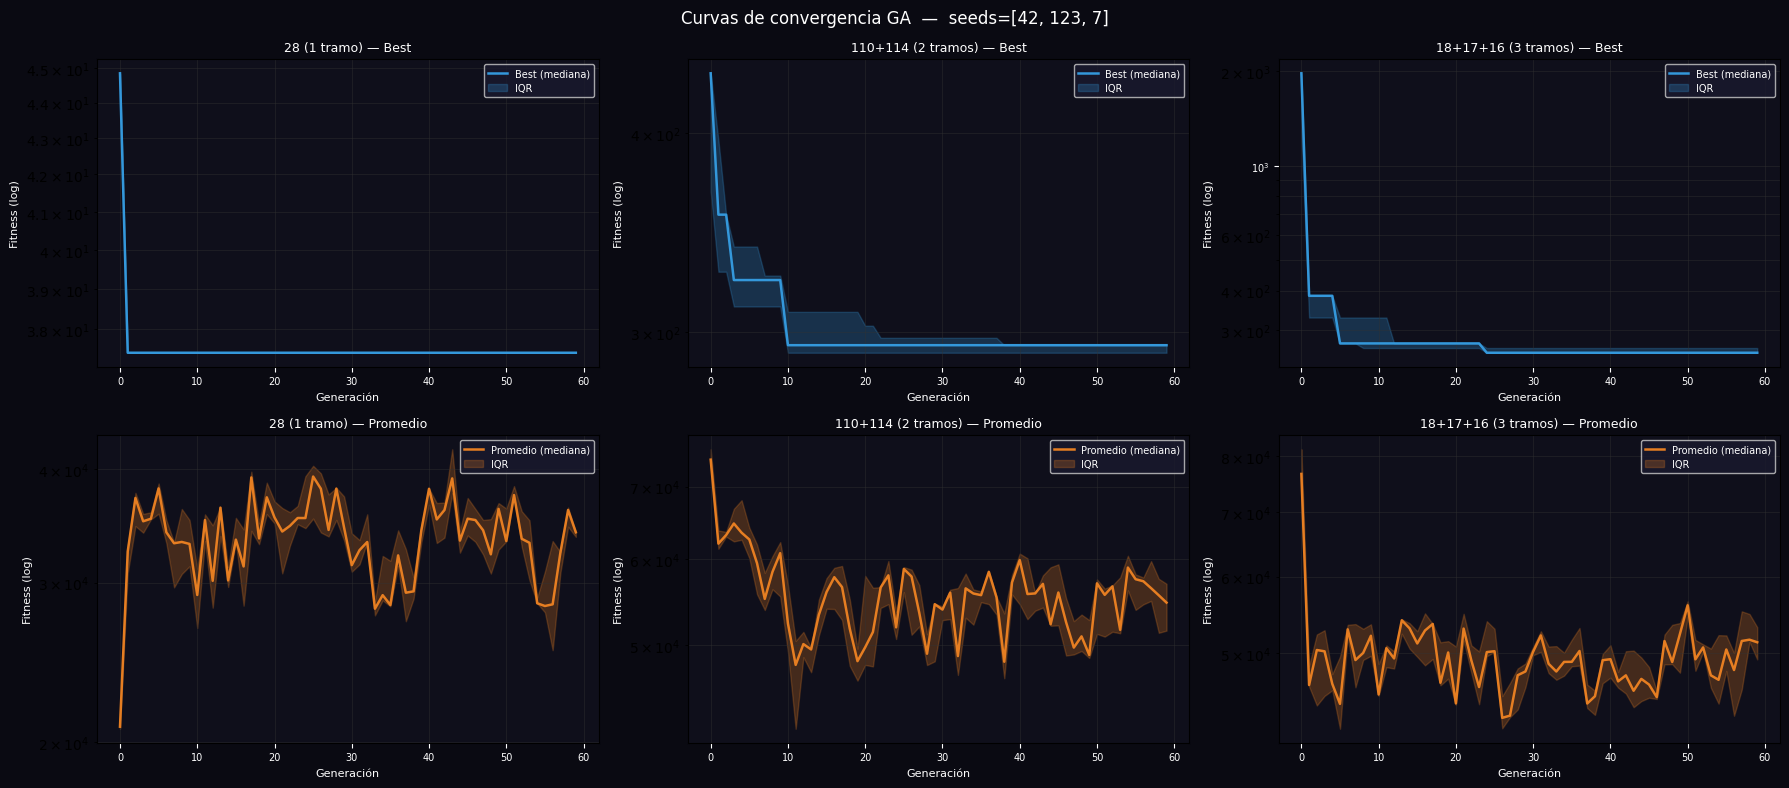

Guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\convergencia.png


In [13]:
def plot_convergencia(records, out_dir):
    beam_ids = list(dict.fromkeys(r['beam_id'] for r in records))
    n_beams = len(beam_ids)
    fig, axes = plt.subplots(2, n_beams, figsize=(6 * n_beams, 8), squeeze=False)
    fig.patch.set_facecolor('#0a0a12')

    for col, bid in enumerate(beam_ids):
        recs = [r for r in records if r['beam_id'] == bid]
        n_gen = max(len(r['history_best']) for r in recs)

        def pad(h):
            return h + [h[-1]] * (n_gen - len(h))

        best_arr = np.array([pad(r['history_best']) for r in recs])
        mean_arr = np.array([pad(r['history_mean']) for r in recs])
        gens = np.arange(n_gen)
        n_sp = recs[0]['n_spans']

        for row, (arr, label, color) in enumerate([
            (best_arr, 'Best', '#3498db'),
            (mean_arr, 'Promedio', '#e67e22'),
        ]):
            ax = axes[row][col]
            ax.set_facecolor('#0f0f1b')
            med = np.median(arr, axis=0)
            lo  = np.percentile(arr, 25, axis=0)
            hi  = np.percentile(arr, 75, axis=0)
            ax.semilogy(gens, med, color=color, lw=1.8, label=f'{label} (mediana)')
            ax.fill_between(gens, lo, hi, color=color, alpha=0.25, label='IQR')
            ax.set_title(
                f"{bid} ({n_sp} tramo{'s' if n_sp > 1 else ''}) — {label}",
                color='white', fontsize=9
            )
            ax.set_xlabel('Generación', color='white', fontsize=8)
            ax.set_ylabel('Fitness (log)', color='white', fontsize=8)
            ax.tick_params(colors='white', labelsize=7)
            ax.grid(True, which='both', color='#333', alpha=0.4)
            ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')

    fig.suptitle(f'Curvas de convergencia GA  —  seeds={SEEDS}',
                 color='white', fontsize=12)
    plt.tight_layout()
    path = out_dir / 'convergencia.png'
    plt.savefig(path, dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'Guardado: {path}')

plot_convergencia(records, OUT_DIR)

---
## 4. Tabla de ablaciones

Media ± std por viga a través de las seeds.

In [14]:
def tabla_ablaciones(records):
    beam_ids = list(dict.fromkeys(r['beam_id'] for r in records))
    print(f"{'Viga':<20} {'n_sp':>4} {'W̄(kg)':>9} {'σW':>7} "
          f"{'Feas%':>6} {'Zones':>8} {'Tconv̄':>7} {'t̄(s)':>7}")
    print('─' * 72)

    rows = []
    for bid in beam_ids:
        recs = [r for r in records if r['beam_id'] == bid]
        W    = [r['weight_kg'] for r in recs]
        feas = [int(r['feasible']) for r in recs]
        frat = [r['feas_rate'] for r in recs]
        cgen = [r['conv_gen'] for r in recs]
        tsec = [r['time_s'] for r in recs]
        n_sp = recs[0]['n_spans']
        n_z  = recs[0]['n_zones']

        row = dict(
            beam_id   = bid,
            n_spans   = n_sp,
            W_mean    = round(np.mean(W), 2),
            W_std     = round(np.std(W),  2),
            feas_pct  = round(np.mean(feas) * 100, 1),
            zones_med = round(np.mean(frat) * n_z, 1),
            n_zones   = n_z,
            conv_mean = round(np.mean(cgen), 1),
            time_mean = round(np.mean(tsec), 1),
        )
        rows.append(row)
        print(f"{bid:<20} {n_sp:>4} {row['W_mean']:>9.2f} {row['W_std']:>7.2f} "
              f"{row['feas_pct']:>5.1f}% "
              f"{row['zones_med']:.1f}/{n_z:>2} "
              f"{row['conv_mean']:>7.1f} {row['time_mean']:>7.1f}")
    return rows

abl_rows = tabla_ablaciones(records)

Viga                 n_sp    W̄(kg)      σW  Feas%    Zones  Tconv̄   t̄(s)
────────────────────────────────────────────────────────────────────────
28                      1     37.43    0.00 100.0% 6.0/ 6     1.0    17.6
110+114                 2    232.59    0.37 100.0% 12.0/12    10.7    41.9
18+17+16                3    249.64    5.75 100.0% 18.0/18    11.0    59.6


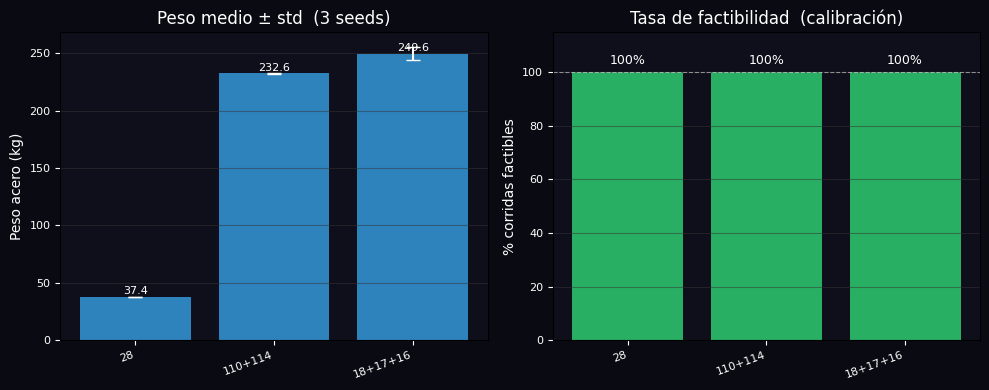

Guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\ablaciones.png


In [15]:
def plot_ablaciones(abl_rows, out_dir):
    labels   = [r['beam_id'] for r in abl_rows]
    W_means  = [r['W_mean']  for r in abl_rows]
    W_stds   = [r['W_std']   for r in abl_rows]
    feas_pct = [r['feas_pct'] for r in abl_rows]

    x = np.arange(len(labels))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.patch.set_facecolor('#0a0a12')

    for ax in (ax1, ax2):
        ax.set_facecolor('#0f0f1b')
        ax.tick_params(colors='white', labelsize=8)
        ax.grid(True, axis='y', color='#333', alpha=0.5)

    # Peso medio ± std
    bars = ax1.bar(x, W_means, yerr=W_stds, color='#3498db',
                   error_kw=dict(ecolor='white', capsize=5, lw=1.5),
                   alpha=0.85)
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=20, ha='right',
                                             color='white', fontsize=8)
    ax1.set_ylabel('Peso acero (kg)', color='white')
    ax1.set_title('Peso medio ± std  (3 seeds)', color='white')
    for bar, val in zip(bars, W_means):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', color='white', fontsize=8)

    # Tasa de factibilidad
    colors = ['#2ecc71' if p == 100 else '#e74c3c' if p == 0 else '#f39c12'
              for p in feas_pct]
    ax2.bar(x, feas_pct, color=colors, alpha=0.85)
    ax2.axhline(100, color='white', lw=0.8, ls='--', alpha=0.5)
    ax2.set_ylim(0, 115)
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=20, ha='right',
                                             color='white', fontsize=8)
    ax2.set_ylabel('% corridas factibles', color='white')
    ax2.set_title('Tasa de factibilidad  (calibración)', color='white')
    for xi, val in zip(x, feas_pct):
        ax2.text(xi, val + 2, f'{val:.0f}%', ha='center', va='bottom',
                 color='white', fontsize=9)

    plt.tight_layout()
    path = out_dir / 'ablaciones.png'
    plt.savefig(path, dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Guardado: {path}')

plot_ablaciones(abl_rows, OUT_DIR)

---
## 6. Tasa de factibilidad por zona

Para cada beam: qué porcentaje de zonas (LEFT/MID/RIGHT × TOP/BOT × tramo) están satisfechas.

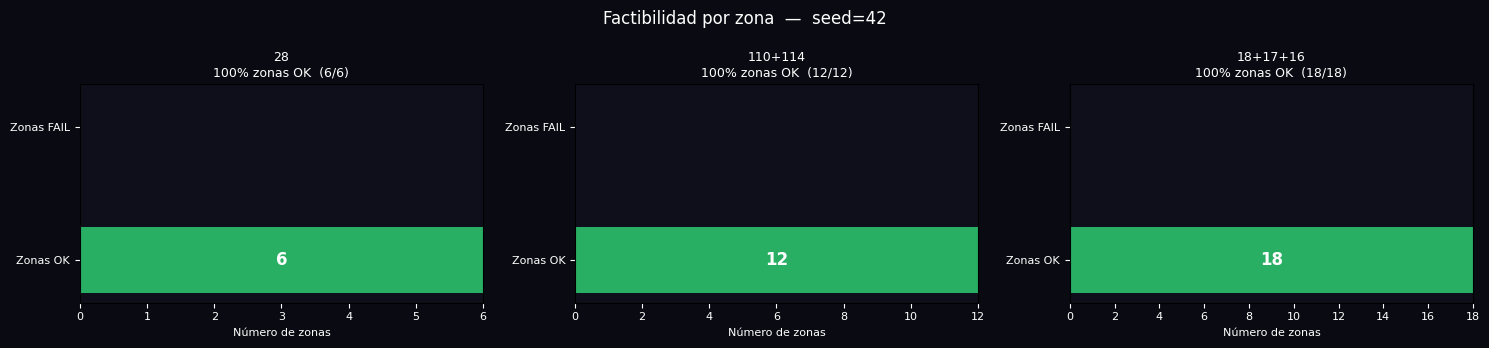

Guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\factibilidad_zonas.png


In [17]:
def plot_factibilidad_zonas(records, out_dir):
    seed42 = [r for r in records if r['seed'] == SEEDS[0]]
    n = len(seed42)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.5), squeeze=False)
    fig.patch.set_facecolor('#0a0a12')

    for col, rec in enumerate(seed42):
        ax = axes[0][col]
        ax.set_facecolor('#0f0f1b')

        ok    = rec['zones_ok']
        total = rec['n_zones']
        fail  = total - ok

        ax.barh(['Zonas OK', 'Zonas FAIL'], [ok, fail],
                color=['#2ecc71', '#e74c3c'], alpha=0.85, height=0.5)
        ax.set_xlim(0, total)
        ax.axvline(total, color='white', lw=0.6, ls='--', alpha=0.4)
        ax.text(ok / 2, 0, str(ok), ha='center', va='center',
                color='white', fontweight='bold', fontsize=12)
        if fail > 0:
            ax.text(ok + fail / 2, 1, str(fail), ha='center', va='center',
                    color='white', fontweight='bold', fontsize=12)

        pct = ok / total * 100
        n_sp = rec['n_spans']
        ax.set_title(
            f"{rec['beam_id']}\n{pct:.0f}% zonas OK  ({ok}/{total})",
            color='white', fontsize=9
        )
        ax.tick_params(colors='white', labelsize=8)
        ax.set_xlabel('Número de zonas', color='white', fontsize=8)

    fig.suptitle(
        f'Factibilidad por zona  —  seed={SEEDS[0]}',
        color='white', fontsize=12
    )
    plt.tight_layout()
    path = out_dir / 'factibilidad_zonas.png'
    plt.savefig(path, dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Guardado: {path}')

plot_factibilidad_zonas(records, OUT_DIR)

---
## 7. Log completo con timestamp

Guarda config + métricas + timestamp en JSON. Cumple el checklist del Sprint 2.

In [18]:
def save_log(records, abl_rows, out_dir):
    ts = datetime.now().isoformat(timespec='seconds')

    log = {
        'timestamp'   : ts,
        'config': {
            'seeds'    : SEEDS,
            'quick'    : QUICK,
            'pop_quick': POP_QUICK,
            'gen_quick': GEN_QUICK,
        },
        'resumen_por_viga': [
            {
                'beam_id'  : r['beam_id'],
                'n_spans'  : r['n_spans'],
                'W_mean_kg': r['W_mean'],
                'W_std_kg' : r['W_std'],
                'feas_pct' : r['feas_pct'],
                'conv_gen_mean': r['conv_mean'],
                'time_s_mean'  : r['time_mean'],
            }
            for r in abl_rows
        ],
        'detalle_corridas': [
            {
                'beam_id'   : r['beam_id'],
                'seed'      : r['seed'],
                'weight_kg' : r['weight_kg'],
                'feasible'  : r['feasible'],
                'zones_ok'  : r['zones_ok'],
                'n_zones'   : r['n_zones'],
                'conv_gen'  : r['conv_gen'],
                'time_s'    : r['time_s'],
                'violations': r['violations'],
            }
            for r in records
        ]
    }

    path = out_dir / f'log_sprint2_{ts.replace(":", "-")}.json'
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(log, f, indent=2, ensure_ascii=False)

    print(f'Log guardado: {path}')
    print(f'  Seeds fijadas: {SEEDS}')
    print(f'  Quick mode: {QUICK}')
    print(f'  Corridas totales: {len(records)}')
    return log

log = save_log(records, abl_rows, OUT_DIR)

Log guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\log_sprint2_2026-05-29T19-28-30.json
  Seeds fijadas: [42, 123, 7]
  Quick mode: True
  Corridas totales: 9


---
## Resumen para la presentación

| Figura | Qué muestra | Slide del profe |
|---|---|---|
| `convergencia.png` | Fitness vs generación (banda IQR entre seeds) | Learning curves |
| `ablaciones.png` | Peso ± std + % factible por viga | Ablaciones + calibración |
| `penalizaciones.png` | Desglose del fitness en términos de penalización | Importancia de variables |
| `factibilidad_zonas.png` | Zonas OK vs FAIL por viga | Calibración |
| `log_sprint2_*.json` | Config + métricas + timestamp | Logs completos |

---
## 8. Armados — diagrama de momentos, elevación y secciones

Corre el GA con seed=42 para cada viga y genera la figura completa de armado.

In [19]:
import subprocess
from IPython.display import Image, display

ARMADOS_DIR = OUT_DIR / 'armados'
ARMADOS_DIR.mkdir(exist_ok=True)

SCRIPT = str(ROOT / 'run_inference_n.py')

for beam_file in BEAM_FILES:
    print(f"\nGenerando armado: {beam_file.name} ...")
    result = subprocess.run(
        [
            sys.executable, SCRIPT,
            '--source', 'json',
            '--json_beam', str(beam_file),
            '--seed', '42',
            '--pop',  str(POP_QUICK),
            '--gen',  str(GEN_QUICK),
            '--h_col_default',
            '--save', str(ARMADOS_DIR),
        ],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("ERROR:", result.stderr[-500:])
    else:
        # Mostrar las figuras generadas para esta viga
        figs = sorted(ARMADOS_DIR.glob(f"result_*rank1*.png"))
        if not figs:
            figs = sorted(ARMADOS_DIR.glob("result_*.png"))
        for fig_path in figs[-1:]:   # mostrar solo rank 1
            print(f"  {fig_path.name}")
            display(Image(filename=str(fig_path), width=1000))


Generando armado: beam_viga_1_tramos.json ...

Generando armado: beam_viga_2_tramos.json ...

Generando armado: beam_viga_3_tramos.json ...
